#  Variance Threshold Feature Selection

**Variance Thresholding** is an **unsupervised, filter-based** feature selection technique used to clean and reduce the dimensionality of an input feature matrix. Unlike supervised selection workflows (such as recursive feature elimination or mutual information metrics), it evaluates the internal data patterns of individual features independently, without referencing the target variable ($y$).

### Core Definitions

*   **Variance ($\sigma^2$):** A statistical measure quantifying how far a set of data numbers are spread out from their average value. It serves as a mathematical proxy for the amount of "information" a column carries.

*   **Constant Feature:** A column where every single cell contains the exact same value ($\sigma^2 = 0$).

*   **Quasi-Constant Feature:** A column where the vast majority of cells contain the same value, with only an extremely small number of exceptions ($\sigma^2 \approx 0$).



## 2. Mathematical Architecture

The algorithm calculates the sample variance for each feature vector independently:

$$\sigma^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2$$

Where:
*   $\mathbf{n}$ = The total number of rows (samples) in the dataset.
*   $\mathbf{x_i}$ = The specific data point value for sample $i$.
*   $\mathbf{\mu}$ = The arithmetic mean of the feature, calculated across all rows: $\mu = \frac{1}{n}\sum x_i$.

### The Strategic Decision Rule
Given a user-defined threshold, $\tau$ (tau):

$$\text{Keep Feature } X_j \iff \sigma^2_{X_j} > \tau$$
$$\text{Drop Feature } X_j \iff \sigma^2_{X_j} \le \tau$$



## 3. Selecting the Variance Threshold Value ($\tau$)

Choosing the optimal value for $\tau$ depends completely on the statistical distribution and data type of the feature column:

### A. Binary and One-Hot Encoded Features (Bernoulli Distribution)

For columns containing only 0 and 1 values, the data follows a Bernoulli distribution. The mathematical variance is bounded and calculated using the probability $p$ of the feature being equal to 1:

$$\sigma^2 = p(1 - p)$$

When stripping out quasi-constant binary columns where a single class dominates the rows, calculate $\tau$ using the targeted probability ratio:
*   **To drop 80/20 splits** (where more than 80% of rows are identical): $\tau = 0.8 \times (1 - 0.8) = \mathbf{0.16}$
*   **To drop 90/10 splits** (where more than 90% of rows are identical): $\tau = 0.9 \times (1 - 0.9) = \mathbf{0.09}$
*   **To drop 95/5 splits** (where more than 95% of rows are identical): $\tau = 0.95 \times (1 - 0.95) = \mathbf{0.0475}$

### B. Continuous Features (The Scale Sensitivity Rule)

For continuous variables, variance scales exponentially with the unit of measurement. For instance, a column for "Annual Income in Dollars" will yield a massive variance, while "Customer Age in Years" will yield a relatively small variance, regardless of which one is more informative.

*   **Operational Requirement:** You must pass your continuous data through a scaling transformer (such as `MinMaxScaler` or `StandardScaler`) **before** applying variance thresholding. Scaling standardizes all continuous variables to the same relative domain, allowing you to set a baseline threshold (e.g., $\tau = 0.01$) across the entire feature space.





In [391]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

from scipy.stats import ttest_ind
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100


# 1. Load Data Set & Inspect

In [397]:
# Importing Data set 
df = pd.read_csv('../DataSets/SECOM.csv')
df.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [398]:
# Extracting features and target variable 
X = df.drop(columns=["Time", "Pass/Fail"], axis=1)
y = df['Pass/Fail']



print(f"Shape of Feature Matrix : {X.shape} | Target Matrix : {y.shape}")
print("Class Balance in Target Variable :")
print(y.value_counts())

Shape of Feature Matrix : (500, 590) | Target Matrix : (500,)
Class Balance in Target Variable :
Pass/Fail
-1    441
 1     59
Name: count, dtype: int64


#### Observation:

- 590 raw sensor features, only 500 wafers, and the classes
are heavily imbalanced (441 pass vs 59 fail). This kind of wide, sparse, high-dimensional sensor data

- This is exactly where Variance Threshold earns its
keep as a *cheap first pass* before anything more expensive (chi2, mutual information, a model) runs on the survivors.

# 2. Handle Missing Data

In [399]:
# Count NaN values in each column 
nan_counts = X.isna().sum()

print(f"Columns with at least one NaN value : {(nan_counts > 0).sum()}")
print(f"Columns that are Entirely NaN : {(nan_counts == len(X)).sum()}")
nan_counts[nan_counts > 0].sort_values(ascending=False).sample(4)

Columns with at least one NaN value : 270
Columns that are Entirely NaN : 16


555    110
328      2
304      1
404      6
dtype: int64

### 2.1 Dropping Zero value Columns

In [400]:
# Fully - empty columns carry Zero information and can be dropped.
fully_empty = nan_counts[nan_counts == len(X)].index.tolist()
X.drop(fully_empty, axis=1, inplace=True)
y = y.loc[X.index]

# Remaining gaps: median-impute per column (unsupervised, doesn't touch target,
# and median is robust to the outlier-heavy sensor scales )
feature_columns = X.columns
median_imputer = SimpleImputer(strategy='median')
X = median_imputer.fit_transform(X)

X = pd.DataFrame(X, columns=feature_columns , index=df.index)

print(f"Dropped Columns : {len(fully_empty)}")
print(f"Remaining NaN values : {(X.isna().sum() > 0).sum()}")
print(f"Remaining Feature Shape: {X.shape} | Target Shape: {y.shape}")


Dropped Columns : 16
Remaining NaN values : 0
Remaining Feature Shape: (500, 574) | Target Shape: (500,)


### 2.2 Computing Variance 

In [401]:
manual_var = X.var().sort_values()

print("---- Lowest-Variance Features ----")
print(manual_var.sample(4))

print("\n---- Highest-Variance Features ----")
print(manual_var.tail(4))

zero_var = (manual_var == 0).sum()
print(f"Number of Features with Zero Variance(Truly constant): {zero_var}")

---- Lowest-Variance Features ----
23     1.928481e+06
273    1.788689e+01
89     6.808970e-03
118    5.737961e-05
dtype: float64

---- Highest-Variance Features ----
24     5.583949e+06
297    6.420123e+06
161    1.521546e+07
162    2.731541e+07
dtype: float64
Number of Features with Zero Variance(Truly constant): 122


#### Observation: 

- There's a huge spread — some features are exactly constant
(variance = 0, e.g. a sensor that never moved, or a broken one), while others have variances in the tens of thousands.

- That spread itself is a warning sign, not just  feature-selection fact 

### 2.3 Plot the Distribution of Variance 

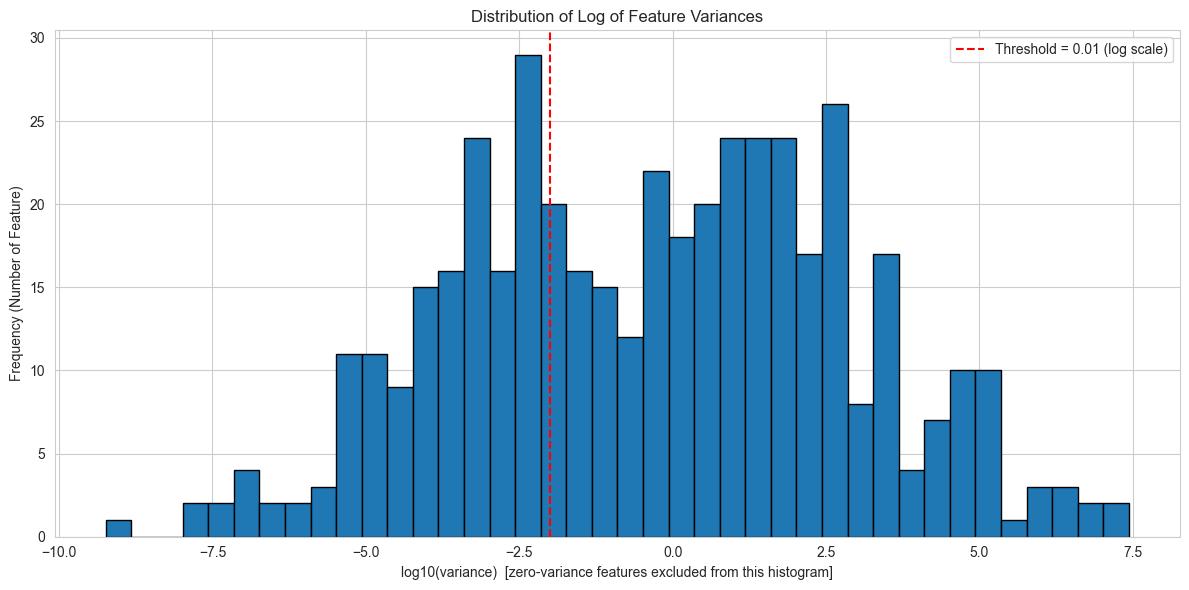

In [408]:
plt.figure(figsize=(12, 6))

plt.hist(np.log10(manual_var.replace(0, np.nan).dropna()), bins=40, edgecolor='black')
plt.axvline(np.log10(0.01), color='red', linestyle='--', label='Threshold = 0.01 (log scale)')
plt.xlabel('log10(variance)  [zero-variance features excluded from this histogram]')
plt.ylabel('Frequency (Number of Feature)')
plt.title('Distribution of Log of Feature Variances')
plt.legend()
plt.tight_layout()
plt.show()


### Conclusion: 

- variance spans many orders of magnitude across features. A single raw threshold like `0.01` would wipe out almost nothing on the high-variance sensors and everything on the low-variance ones.

- but that's an artifact of **units**, not information content. This is the one place Variance Threshold can quietly mislead you, and it's worth m confronting before picking a number.

### 2.4 Low and High Variance

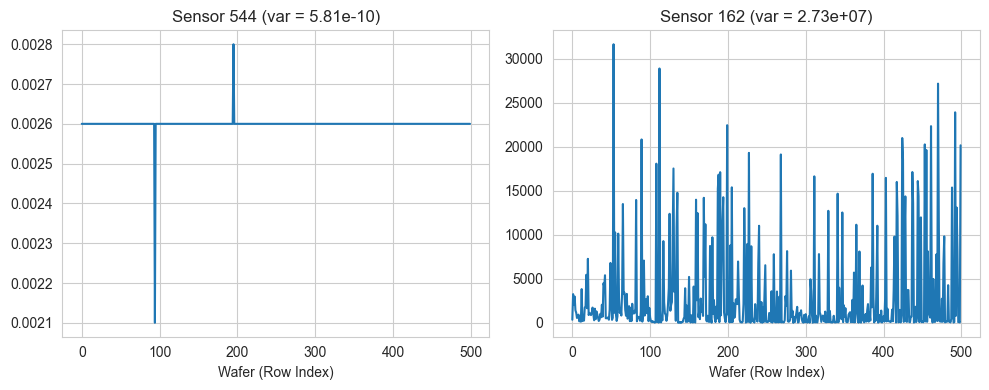

In [403]:
low_var = manual_var[manual_var > 0].index[0]
high_var = manual_var.index[-1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(X[low_var].values)
axes[0].set_title(f'Sensor {low_var} (var = {manual_var[low_var]:.2e})')

axes[1].plot(X[high_var].values)
axes[1].set_title(f'Sensor {high_var} (var = {manual_var[high_var]:.2e})')
for ax in axes:
    ax.set_xlabel("Wafer (Row Index)")
plt.tight_layout()
plt.show()


### What to look for:

- The left sensor barely deviates from a flat line across all 500 wafers — it genuinely looks like it can't distinguish
anything.

- The right one swings hard. That's the intuition Variance Threshold is built on. But this comparison is only fair because we're looking at *each sensor against itself* — comparing the raw variance **numbers** of two sensors with different units (volts vs. counts vs. pressure, say) is not fair.

# 3. Remove exact constants with sklearn (Pass 1)


In [404]:
selector_zero = VarianceThreshold(threshold=0.0)
selector_zero.fit_transform(X)

kept_mask_zero = selector_zero.get_support()
removed_zero = (~kept_mask_zero).sum()

X_pass1 = X.loc[:, kept_mask_zero]
y = y.loc[X_pass1.index] 

print(f"Sklearn (Threshold = 0.0) removes : {removed_zero} features.")
print(f"Manual count of variance = 0.0 features: {zero_var}")
print(f"Shape after pass 1 (Constant removed) :-  Feature :{X_pass1.shape} | Target {y.shape}")

Sklearn (Threshold = 0.0) removes : 122 features.
Manual count of variance = 0.0 features: 122
Shape after pass 1 (Constant removed) :-  Feature :(500, 452) | Target (500,)


### Conclusion:
- sklearn's `VarianceThreshold(threshold=0.0)` agrees exactly with the manual count.
- These constant sensors are unambiguously useless and
safe to drop under any circumstance — no scale argument changes that.

# 4. Variance Threshold on Normalized Data  (Pass 2)


In [405]:
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_pass1),
    columns = X_pass1.columns
)

# on a [0,1] scale now - a much more interpretable number
THRESHOLD = 0.01

selector_2 = VarianceThreshold(threshold=THRESHOLD)
X_pass2 = selector_2.fit_transform(X_scaled)

kept_feature = selector_2.get_support()

print(f"Threshold = {THRESHOLD} on normalized scale")
print(f"Feature kept : {kept_feature.sum()}")
print(f"Feature dropped: {(~kept_feature).sum()}")

Threshold = 0.01 on normalized scale
Feature kept : 296
Feature dropped: 156


In [406]:
X_pass2 = X_scaled.loc[:, kept_feature]

print("Original :", X.shape[1], "Feature")
print("Pass 1 (Constant ) :", X_pass1.shape[1], "Feature")
print("Pass 2 (low-variance, normalized) :", X_pass2.shape[1], "Feature")

Original : 574 Feature
Pass 1 (Constant ) : 452 Feature
Pass 2 (low-variance, normalized) : 296 Feature


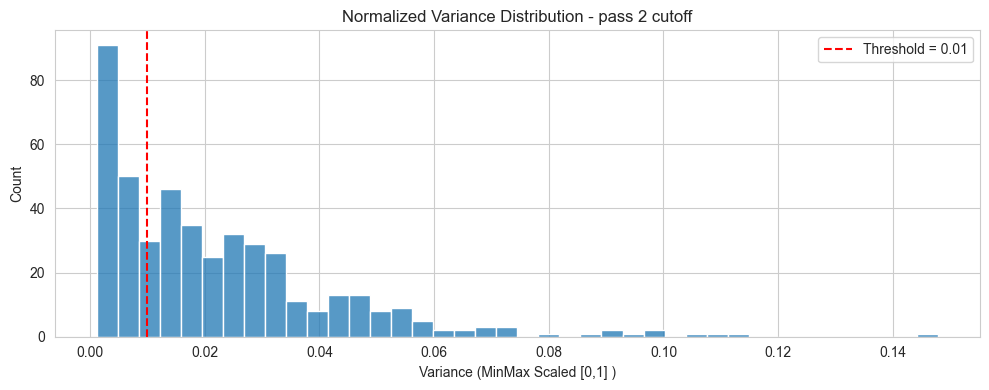

In [409]:
plt.figure(figsize=(10,4))
sns.histplot(X_scaled.var(), bins=40)
plt.axvline(THRESHOLD, color='red', linestyle='--', label=f"Threshold = {THRESHOLD}")
plt.xlabel("Variance (MinMax Scaled [0,1] )")
plt.title("Number of Features")
plt.title("Normalized Variance Distribution - pass 2 cutoff")
plt.legend()
plt.tight_layout()
plt.show()

### Observation: 
- On the normalized scale the variances are far more comparable, and the threshold line actually cuts through a meaningful part of the distribution rather than either doing nothing or removing everything.

# 5. ttest on the features that pass 2 is about to remove 

Variance Threshold never looks at `Pass/Fail`. That means it's possible to throw away a feature that's low-variance overall but still shifts
meaningfully between the Pass and Fail groups (rare, but worth actually checking rather than assuming). Run a quick t-test on the features that
pass 2 is about to remove, comparing Pass vs Fail means.

In [419]:
# Removed cols that passed the variance threshold
removed_cols_pass2 = X_pass1.columns[~kept_feature]

flagged = []

for col in removed_cols_pass2:
    
    # Number of pass and fail values for the feature
    passed = X_pass1.loc[y == -1, col]
    failed = X_pass1.loc[y == 1, col]
    
    # Perform the t-test
    stat, p_value = ttest_ind(passed, failed, equal_var=False, nan_policy='omit')
    flagged.append({"Feature":col, "t_stat": stat, "p_value": p_value})

# Convert the flagged list to a DataFrame and sort by p-value
flagged_df = pd.DataFrame(flagged).sort_values(by="p_value")

print(f"Out of {len(removed_cols_pass2)} features removed in pass 2,",
      f"{(flagged_df['p_value'] < 0.05).sum()} show p < 0.05 on a Pass/Fail t-test.")

flagged_df.head(10)


Out of 156 features removed in pass 2, 6 show p < 0.05 on a Pass/Fail t-test.


/Users/arbazkhan/kael/kael_env/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,Feature,t_stat,p_value
11,59,-2.649758,0.009461
18,73,2.210048,0.027645
104,367,2.178162,0.031381
80,292,1.995795,0.046518
110,390,2.003917,0.046724
41,155,1.979391,0.048342
117,428,1.942427,0.052655
43,157,1.838789,0.066558
70,251,1.780680,0.075617
109,389,1.764788,0.078260


### Conclusion:

- If that count above is non-zero, it's a genuine example of Variance Threshold's blind spot a low-variance feature that still carries a (weak)target-relevant signal. 

- In practice on SECOM this number is usually small, and given how heavily imbalanced the classes are (59 fails out of 500) any single t-test here should be read with real skepticism —but it's the right habit to form: **an unsupervised filter's "removed" pile is worth a quick supervised sanity check before you consider it final**, especially when the downstream task genuinely cares about the rare class.


# 6. Summary Table

In [410]:
summary = pd.DataFrame({
    "Stages":["Original","Pass 1 (Constant Features Removed)", "Pass 2 (Variance Threshold)"],
    "Number of Features ": [X.shape[1], X_pass1.shape[1], X_pass2.shape[1]]
})


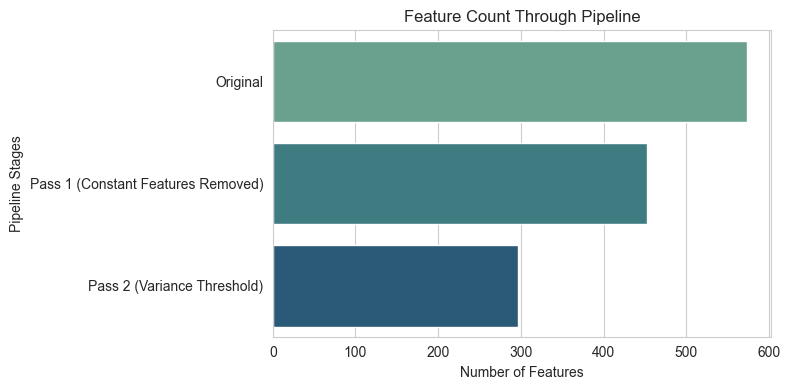

,Stages,Number of Features
0,Original,574
1,Pass 1 (Constant Features Removed),452
2,Pass 2 (Variance Threshold),296


In [411]:
plt.figure(figsize=(8,4))
sns.barplot(data=summary, x="Number of Features ", y="Stages", hue="Stages", palette="crest")
plt.title("Feature Count Through Pipeline")
plt.xlabel("Number of Features")
plt.ylabel("Pipeline Stages")
plt.tight_layout()
plt.show()
summary

## 7. Model Training and Comparison

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score,
    confusion_matrix
)


# Model Training Function
def Model_Training(X,y, scaled=True):

    if ~scaled:
        standScaler = MinMaxScaler()
        X = pd.DataFrame(
                standScaler.fit_transform(X),
                columns = X.columns
            )
    
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
    
    # Train the model 
    model = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)
    
    # Make predictions 
    y_pred = model.predict(X_test)
    y_probability = model.predict_proba(X_test)[:, 1]
    
    # Calculate the calculate metrics
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label=1),
        "Recall": recall_score(y_test, y_pred, pos_label=1),
        "F1": f1_score(y_test, y_pred, pos_label=1),
        "ROC-AUC": roc_auc_score(y_test, y_probability),
        "PR-AUC": average_precision_score(y_test, y_probability),
    }

    return metrics


### 7.1 Model Performance on Different Stages of Data

In [ ]:
# Training Model On different Stages of Data 
Model_Original = Model_Training(X,y, scaled=False)
Model_Pass1 = Model_Training(X_pass1,y, scaled=False)
Model_Pass2 = Model_Training(X_pass2,y, scaled=True)


# Create a DataFrame to store the results
results = pd.DataFrame({
    "Original": Model_Original,
    "Pass 1": Model_Pass1,
    "Pass 2": Model_Pass2
}).T

results

,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Original,0.75,0.495847,0.133333,0.142857,0.137931,0.633721,0.188564
Pass 1,0.75,0.495847,0.133333,0.142857,0.137931,0.633721,0.188564
Pass 2,0.76,0.501661,0.142857,0.142857,0.142857,0.648671,0.207167


### 7.2 Accuracy Comparison 

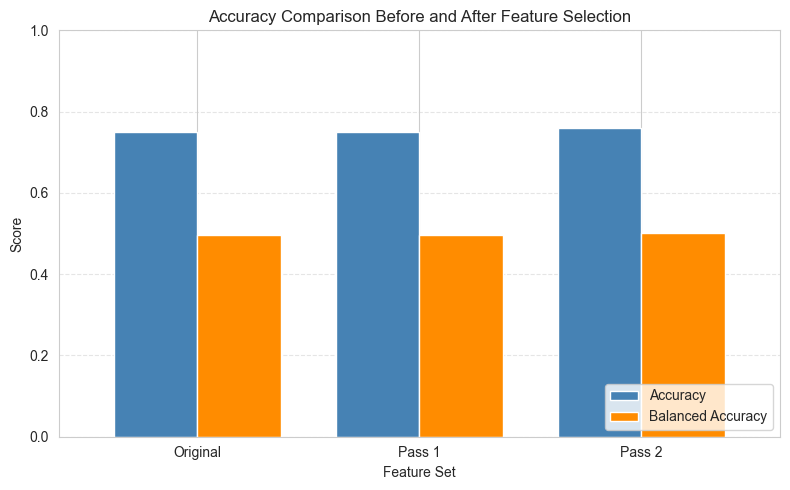

,Accuracy,Balanced Accuracy
Original,0.75,0.495847
Pass 1,0.75,0.495847
Pass 2,0.76,0.501661


In [416]:
# Accuracy Comparison Before and After Feature Selection
main_metrics = results[["Accuracy", "Balanced Accuracy"]]

main_metrics.plot(
    kind="bar",
    figsize=(8, 5),
    ylim=(0, 1),
    width=0.75,
    color=["steelblue", "darkorange"]
)

plt.title("Accuracy Comparison Before and After Feature Selection")
plt.ylabel("Score")
plt.xlabel("Feature Set")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
main_metrics

### 7.3 Other Metrics Comparison

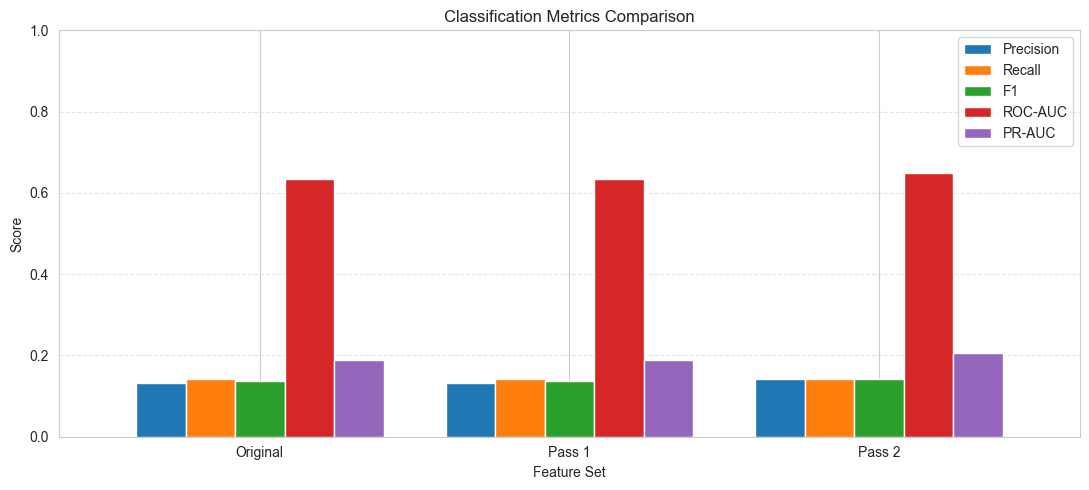

,Precision,Recall,F1,ROC-AUC,PR-AUC
Original,0.133333,0.142857,0.137931,0.633721,0.188564
Pass 1,0.133333,0.142857,0.137931,0.633721,0.188564
Pass 2,0.142857,0.142857,0.142857,0.648671,0.207167


In [418]:
# Other Classification Metrics Before and After Feature Selection
other_metrics = results[
    ["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
]

other_metrics.plot(
    kind="bar",
    figsize=(11, 5),
    ylim=(0, 1),
    width=0.8
)

plt.title("Classification Metrics Comparison")
plt.ylabel("Score")
plt.xlabel("Feature Set")
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
other_metrics


## 8. Strategic Rules: When to Use vs. When to Avoid

### When to Use

*   **Initial Pipeline Data Cleaning:** It should serve as the very first step in your feature selection pipeline to eliminate completely static columns ($\tau = 0$).

*   **High-Dimensional Sparsity:** Highly beneficial when working with sparse text classification data (e.g., TF-IDF matrices or Bag-of-Words frameworks) where thousands of tokens appear only once or twice across millions of rows.

*   **Rapid Computational Filtering:** Ideal when working with massive big data systems because it handles computations in parallel with low overhead.

### When to Avoid

*   **Unscaled Continuous Data:** Never use it on unnormalized continuous numeric columns. It will mistakenly drop highly descriptive variables purely because their native numeric range is small.

*   **Highly Unbalanced Imbalanced Datasets:** If you are building a model specifically to detect an extremely rare event (e.g., fraud occurring in only 0.1% of transactions), an incredibly low-variance feature might be the exact signal that flags the rare anomaly. Wiping out columns with low variance in this context will ruin model sensitivity.



## 9. Model Impact: Performance Analysis

Variance thresholding alters the training dynamics of machine learning algorithms differently depending on their internal mathematical designs:

### Models that Show Significant Performance Improvements

*   **Distance-Based Models (k-NN, SVMs, Clustering):** Algorithms like K-Nearest Neighbors and Support Vector Machines rely heavily on distance metrics (e.g., Euclidean distance). Keeping low-variance or constant features dilutes the distance calculations with meaningless noise, degrading the model's accuracy. Wiping out these columns restores proper spatial representations.

*   **Linear & Logistic Regression:** Columns with zero variance cause perfect multicollinearity or matrix singularity errors during Ordinary Least Squares (OLS) optimization. Removing them prevents mathematical collapse and stabilizes the regression coefficients.

*   **Neural Networks:** Reducing uninformative inputs simplifies the optimization landscape, preventing gradients from updating based on constant noise columns and leading to faster loss convergence.

### Models that Show Negligible to No Performance Improvements

*   **Tree-Based Ensembles (Random Forests, Gradient Boosting, XGBoost):** Modern tree architectures are natively resilient to low-variance noise. When a decision tree calculates the optimal split point for a node using information gain (Gini or Entropy), it naturally bypasses low-variance or constant columns because they cannot be split cleanly to create pure child nodes. While removing these features will speed up training time, it rarely alters the final accuracy metrics of the model.


## 10. Critical Missing Pieces: Multicollinearity

The biggest analytical vulnerability of Variance Thresholding is its **inability to detect multicollinearity**. 

Because the algorithm only looks at features one by one (univariate analysis), it cannot detect when columns are redundant copies of each other. For example, if your dataset contains three identical columns for "Total Balance" with high variance, Variance Thresholding will eagerly keep all three of them. 

To build a secure feature selection pipeline, you should always follow a Variance Threshold pass with a multivariate method (such as **Correlation Matrix Filtering** or **Variance Inflation Factor (VIF)**) to strip out redundant data structures.